# 03 · Peer Benchmarking

Is FormFactor's ~40% gross margin good or bad? Was the 2023 decline company-specific or industry-wide? Answering requires peers.

The pipeline from notebook 01 is packaged in `sec_etl.py` and applied to five U.S.-listed companies in the semiconductor test and packaging value chain:

| Ticker | Company | Business | Relevance |
|---|---|---|---|
| **FORM** | FormFactor | Probe cards, engineering probe systems | Subject |
| TER | Teradyne | Automatic test equipment (ATE) | Same test step; probe cards mount on ATE |
| COHU | Cohu | Test handlers, contactors, ATE | Same test step, similar scale |
| ONTO | Onto Innovation | Process control, advanced-packaging inspection | Yield management, advanced packaging exposure |
| KLIC | Kulicke & Soffa | Assembly and advanced-packaging equipment | Same customers and cycle |

Direct probe-card competitors (Technoprobe, Micronics Japan, Chunghwa Precision Test) are not SEC filers; they are covered in notebook 04 using their own reports.

## Setup

In [1]:
import sqlite3
from pathlib import Path
import pandas as pd
import sec_etl

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

HEADERS = {"User-Agent": "Chen-Chih Hung cosby432@gmail.com"}   # replace with your own

BASE = Path.cwd()
RAW_DIR = BASE / "data" / "raw"
CLEAN_DIR = BASE / "data" / "clean"
OUT_DIR = BASE / "data" / "analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)
DB_PATH = BASE / "data" / "formfactor.db"

PEERS = {  # ticker: (CIK, name, segment, fiscal year-end)
    "FORM": ("1039399", "FormFactor",      "Probe cards & test systems", "Dec"),
    "TER":  ("97210",   "Teradyne",        "Automatic test equipment",   "Dec"),
    "COHU": ("21535",   "Cohu",            "Test handlers & contactors", "Dec"),
    "ONTO": ("704532",  "Onto Innovation", "Metrology & inspection",     "Dec"),
    "KLIC": ("56978",   "Kulicke & Soffa", "Assembly & packaging equip", "Sep/Oct"),
}

## 1. Build the peer dataset

In [2]:
frames, reports = [], []
for ticker, (cik, name, _, _) in PEERS.items():
    long_df, report = sec_etl.build_company(ticker, cik, HEADERS, raw_dir=RAW_DIR)
    frames.append(long_df)
    reports.append(report)
    print(f"{ticker:5s} {name:16s} {len(long_df):4d} rows  FY{long_df.fiscal_year.min()}–FY{long_df.fiscal_year.max()}")

peers_long = pd.concat(frames, ignore_index=True)
reports = pd.concat(reports, ignore_index=True)

FORM  FormFactor        279 rows  FY2016–FY2025


TER   Teradyne          258 rows  FY2016–FY2025


COHU  Cohu              266 rows  FY2016–FY2025
ONTO  Onto Innovation   266 rows  FY2016–FY2025


KLIC  Kulicke & Soffa   269 rows  FY2016–FY2025


### 1.1 Tag coverage

Every metric is either reported (`ok`) or derived from an identity (`derived`): Onto reports selling and G&A expenses separately, and Cohu does not report total liabilities. Cohu also switched in 2021 to a cost-of-revenue tag that **excludes D&A**, which slightly overstates its gross margin.

In [3]:
coverage = reports.pivot_table(index="metric", columns="ticker", values="status", aggfunc="first")
coverage[(coverage != "ok").any(axis=1)]

ticker,COHU,FORM,KLIC,ONTO,TER
metric,,,,,
sga_expense,ok,ok,ok,derived,ok
total_liabilities,derived,ok,ok,ok,ok


### 1.2 Reconcile revenue with reported figures (USD m)

In [4]:
rev = peers_long[peers_long["metric"] == "revenue"].pivot_table(index="fiscal_year", columns="ticker", values="value") / 1e6

expected = {("FORM", 2025): 785.0, ("TER", 2025): 3190.0, ("COHU", 2025): 453.0,
            ("ONTO", 2024): 987.3, ("KLIC", 2025): 654.1}
for (t, y), v in expected.items():
    assert abs(rev.loc[y, t] - v) < 1, f"{t} {y} revenue mismatch"
print("All peer revenues reconcile to reported figures")
rev[list(PEERS)].round(1)

All peer revenues reconcile to reported figures


ticker,FORM,TER,COHU,ONTO,KLIC
fiscal_year,,,,,
2016,383.90,"1,753.20",282.10,221.10,627.20
2017,548.40,"2,136.60",352.70,255.10,809.00
2018,529.70,"2,100.80",451.80,273.80,889.10
2019,589.50,"2,295.00",583.30,305.90,540.10
2020,693.60,"3,121.50",636.00,556.50,623.20
2021,769.70,"3,702.90",887.20,788.90,"1,517.70"
2022,747.90,"3,155.00",812.80,"1,005.20","1,503.60"
2023,663.10,"2,676.30",636.30,815.90,742.50
2024,763.60,"2,819.90",401.80,987.30,706.20


Known distortions: Onto Innovation was formed by the October 2019 merger of Nanometrics and Rudolph Technologies, so its 2019 revenue is understated relative to later years. Kulicke & Soffa's fiscal year ends in late September or early October, about one quarter ahead of the others.

## 2. Load into the database

A `companies` dimension table holds descriptive attributes once; the `financials` fact table holds the numbers. Loads delete then insert by ticker, so re-runs are safe.

In [5]:
peers_long.to_csv(CLEAN_DIR / "peers_financials_long.csv", index=False)

conn = sqlite3.connect(DB_PATH)
def q(sql):
    return pd.read_sql_query(sql, conn)

companies = pd.DataFrame([(t, c, n, s, f) for t, (c, n, s, f) in PEERS.items()],
                         columns=["ticker", "cik", "company_name", "segment", "fiscal_year_end"])
conn.execute("DROP TABLE IF EXISTS companies")
conn.execute("CREATE TABLE companies (ticker TEXT PRIMARY KEY, cik TEXT, company_name TEXT, segment TEXT, fiscal_year_end TEXT)")
companies.to_sql("companies", conn, if_exists="append", index=False)

conn.execute(f"DELETE FROM financials WHERE ticker IN ({','.join('?' * len(PEERS))})", list(PEERS))
peers_long.to_sql("financials", conn, if_exists="append", index=False)
conn.commit()

q("""
SELECT c.company_name, COUNT(*) AS rows, MIN(f.fiscal_year) AS first_fy, MAX(f.fiscal_year) AS last_fy
FROM financials f JOIN companies c ON f.ticker = c.ticker
GROUP BY c.company_name ORDER BY rows DESC
""")

,company_name,rows,first_fy,last_fy
0,FormFactor,279,2016,2025
1,Kulicke & Soffa,269,2016,2025
2,Onto Innovation,266,2016,2025
3,Cohu,266,2016,2025
4,Teradyne,258,2016,2025


The `fin_wide` and `ratios` views from notebook 02 already group by `ticker`, so they cover all five companies without changes. They are recreated here so the new metrics are included.

In [6]:
metrics = q("SELECT DISTINCT metric FROM financials ORDER BY metric")["metric"].tolist()
case_lines = ",\n       ".join(f"MAX(CASE WHEN metric = '{m}' THEN value END) AS {m}" for m in metrics)
conn.execute("DROP VIEW IF EXISTS fin_wide")
conn.execute(f"CREATE VIEW fin_wide AS SELECT ticker, fiscal_year, {case_lines} FROM financials GROUP BY ticker, fiscal_year")

conn.execute("DROP VIEW IF EXISTS ratios")
conn.execute("""
CREATE VIEW ratios AS
SELECT ticker, fiscal_year,
       revenue / 1e6                                              AS revenue_musd,
       100.0 * gross_profit     / NULLIF(revenue, 0)              AS gross_margin_pct,
       100.0 * operating_income / NULLIF(revenue, 0)              AS operating_margin_pct,
       100.0 * net_income       / NULLIF(revenue, 0)              AS net_margin_pct,
       100.0 * rd_expense       / NULLIF(revenue, 0)              AS rd_pct_revenue,
       100.0 * sga_expense      / NULLIF(revenue, 0)              AS sga_pct_revenue,
       100.0 * net_income       / NULLIF(total_assets, 0)         AS roa_pct,
       current_assets           / NULLIF(current_liabilities, 0)  AS current_ratio,
       total_liabilities        / NULLIF(total_equity, 0)         AS debt_to_equity,
       (operating_cash_flow - capex) / 1e6                        AS fcf_musd,
       100.0 * (operating_cash_flow - capex) / NULLIF(revenue, 0) AS fcf_margin_pct,
       (cash + COALESCE(st_investments, 0) - COALESCE(long_term_debt, 0)) / 1e6 AS net_cash_musd,
       100.0 * capex            / NULLIF(revenue, 0)              AS capex_pct_revenue,
       100.0 * stock_comp       / NULLIF(revenue, 0)              AS sbc_pct_revenue
FROM fin_wide
""")
conn.commit()

## 3. Latest-year snapshot

`ROW_NUMBER() OVER (PARTITION BY ticker ORDER BY fiscal_year DESC)` selects each company's most recent fiscal year without hard-coding a year, which matters because fiscal year-ends differ.

In [7]:
latest = q("""
WITH ranked AS (
    SELECT r.*, ROW_NUMBER() OVER (PARTITION BY r.ticker ORDER BY r.fiscal_year DESC) AS rn
    FROM ratios r
)
SELECT c.company_name, k.fiscal_year,
       ROUND(k.revenue_musd, 0)         AS revenue_musd,
       ROUND(k.gross_margin_pct, 1)     AS gross_margin,
       ROUND(k.operating_margin_pct, 1) AS op_margin,
       ROUND(k.rd_pct_revenue, 1)       AS rd_pct,
       ROUND(k.capex_pct_revenue, 1)    AS capex_pct,
       ROUND(k.fcf_margin_pct, 1)       AS fcf_margin,
       ROUND(k.debt_to_equity, 2)       AS debt_to_equity
FROM ranked k JOIN companies c ON k.ticker = c.ticker
WHERE k.rn = 1
ORDER BY k.revenue_musd DESC
""")
latest

,company_name,fiscal_year,revenue_musd,gross_margin,op_margin,rd_pct,capex_pct,fcf_margin,debt_to_equity
0,Teradyne,2025,"3,190.00",58.20,20.40,15.80,7.00,14.10,0.50
1,Onto Innovation,2025,"1,005.00",49.70,13.20,13.10,2.80,29.80,0.13
2,FormFactor,2025,785.00,39.30,7.30,14.70,13.20,1.50,0.18
3,Kulicke & Soffa,2025,654.00,42.50,-0.50,22.90,2.60,14.70,0.34
4,Cohu,2025,453.00,42.70,-15.40,20.40,4.60,2.40,0.58


## 4. Revenue growth through the cycle (YoY %)

In [8]:
q("""
WITH yoy AS (
    SELECT ticker, fiscal_year,
           100.0 * (revenue_musd - LAG(revenue_musd) OVER w) / LAG(revenue_musd) OVER w AS rev_yoy
    FROM ratios
    WINDOW w AS (PARTITION BY ticker ORDER BY fiscal_year)
)
SELECT fiscal_year,
       ROUND(MAX(CASE WHEN ticker = 'FORM' THEN rev_yoy END), 1) AS FORM,
       ROUND(MAX(CASE WHEN ticker = 'TER'  THEN rev_yoy END), 1) AS TER,
       ROUND(MAX(CASE WHEN ticker = 'COHU' THEN rev_yoy END), 1) AS COHU,
       ROUND(MAX(CASE WHEN ticker = 'ONTO' THEN rev_yoy END), 1) AS ONTO,
       ROUND(MAX(CASE WHEN ticker = 'KLIC' THEN rev_yoy END), 1) AS KLIC
FROM yoy
WHERE fiscal_year >= 2019
GROUP BY fiscal_year
ORDER BY fiscal_year
""")

,fiscal_year,FORM,TER,COHU,ONTO,KLIC
0,2019,11.30,9.20,29.10,11.70,-39.30
1,2020,17.70,36.00,9.00,81.90,15.40
2,2021,11.00,18.60,39.50,41.80,143.50
3,2022,-2.80,-14.80,-8.40,27.40,-0.90
4,2023,-11.30,-15.20,-21.70,-18.80,-50.60
5,2024,15.20,5.40,-36.90,21.00,-4.90
6,2025,2.80,13.10,12.70,1.80,-7.40


## 5. Indexed revenue

Revenue is indexed to a common base year to compare growth across companies of very different size. The base matters: Teradyne grew 36% and Onto 82% (merger-driven) in 2020, so a 2019 base flatters them. 2020 is used as the base; the ranking under both bases is shown for transparency.

In [9]:
def revenue_index(base_year):
    df = q(f"""
    SELECT ticker, fiscal_year,
           100.0 * revenue_musd / FIRST_VALUE(revenue_musd) OVER (PARTITION BY ticker ORDER BY fiscal_year) AS rev_index
    FROM ratios
    WHERE fiscal_year >= {base_year}
    """)
    return df.pivot(index="fiscal_year", columns="ticker", values="rev_index")[list(PEERS)]

idx_2019, idx_wide = revenue_index(2019), revenue_index(2020)
pd.DataFrame({"2025 index (base 2019)": idx_2019.iloc[-1], "2025 index (base 2020)": idx_wide.iloc[-1]}).round(0)

,2025 index (base 2019),2025 index (base 2020)
ticker,,
FORM,133.00,113.00
TER,139.00,102.00
COHU,78.00,71.00
ONTO,329.00,181.00
KLIC,121.00,105.00


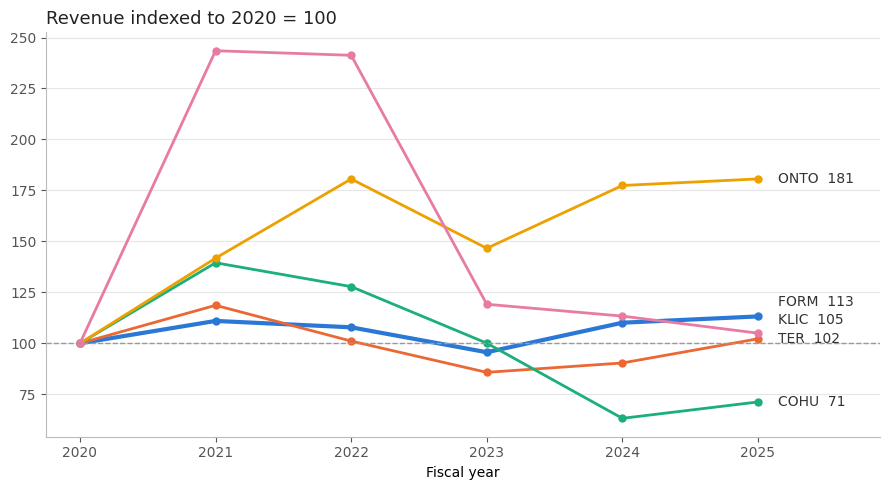

In [10]:
import matplotlib.pyplot as plt

def style(ax):
    """Minimal chart style: no top/right spines, light axes, gridlines behind data."""
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#bbbbbb")
    ax.set_axisbelow(True)
    ax.tick_params(colors="#555555")

COLORS = {"FORM": "#2a78d6", "TER": "#eb6834", "COHU": "#1baf7a", "ONTO": "#eda100", "KLIC": "#e87ba4"}

fig, ax = plt.subplots(figsize=(9, 5))
for t in idx_wide.columns:
    s = idx_wide[t].dropna()
    ax.plot(s.index, s.values, color=COLORS[t], linewidth=3 if t == "FORM" else 2, marker="o", markersize=5)

# Direct labels at line ends, nudged apart when values are close
ends = idx_wide.ffill().iloc[-1].sort_values()
gap = (idx_wide.max().max() - idx_wide.min().min()) * 0.05
label_y, prev = {}, None
for t, v in ends.items():
    y = v if prev is None else max(v, prev + gap)
    label_y[t], prev = y, y
last_x = idx_wide.index.max()
for t, v in ends.items():
    ax.text(last_x + 0.15, label_y[t], f"{t}  {v:.0f}", va="center", color="#333333", fontsize=10)

ax.set_xlim(right=last_x + 0.9)
ax.axhline(100, color="#999999", linewidth=1, linestyle="--")
ax.set_title("Revenue indexed to 2020 = 100", loc="left", fontsize=13, color="#222222")
ax.set_xlabel("Fiscal year")
ax.grid(axis="y", color="#e6e6e6", linewidth=0.8)
style(ax)
plt.tight_layout()
plt.savefig(OUT_DIR / "peer_revenue_index.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Five-year averages (2021–2025) with ranks

FormFactor's operating margin excludes the FY2023 FRT gain via the `one_time_items` table from notebook 02.

In [11]:
avg5 = q("""
WITH adj AS (SELECT ticker, fiscal_year, SUM(amount) AS one_time FROM one_time_items GROUP BY ticker, fiscal_year),
base AS (
    SELECT r.ticker, r.gross_margin_pct, r.rd_pct_revenue, r.capex_pct_revenue, r.fcf_margin_pct,
           100.0 * (f.operating_income - COALESCE(a.one_time, 0)) / f.revenue AS adj_op_margin_pct
    FROM ratios r
    JOIN fin_wide f ON r.ticker = f.ticker AND r.fiscal_year = f.fiscal_year
    LEFT JOIN adj a ON r.ticker = a.ticker AND r.fiscal_year = a.fiscal_year
    WHERE r.fiscal_year BETWEEN 2021 AND 2025
),
summary AS (
    SELECT ticker,
           AVG(gross_margin_pct) AS gross_margin, AVG(adj_op_margin_pct) AS op_margin_adj,
           AVG(rd_pct_revenue) AS rd_pct, AVG(capex_pct_revenue) AS capex_pct, AVG(fcf_margin_pct) AS fcf_margin
    FROM base GROUP BY ticker
)
SELECT ticker,
       ROUND(gross_margin, 1)  AS gross_margin,  RANK() OVER (ORDER BY gross_margin  DESC) AS gm_rank,
       ROUND(op_margin_adj, 1) AS op_margin_adj, RANK() OVER (ORDER BY op_margin_adj DESC) AS opm_rank,
       ROUND(rd_pct, 1)        AS rd_pct,        RANK() OVER (ORDER BY rd_pct        DESC) AS rd_rank,
       ROUND(capex_pct, 1)     AS capex_pct,     RANK() OVER (ORDER BY capex_pct     DESC) AS capex_rank,
       ROUND(fcf_margin, 1)    AS fcf_margin,    RANK() OVER (ORDER BY fcf_margin    DESC) AS fcf_rank
FROM summary
ORDER BY op_margin_adj DESC
""")
avg5

,ticker,gross_margin,gm_rank,op_margin_adj,opm_rank,rd_pct,rd_rank,capex_pct,capex_rank,fcf_margin,fcf_rank
0,TER,58.60,1,23.80,1,14.70,4,5.80,2,17.20,2
1,ONTO,52.30,2,10.00,3,12.20,5,2.40,5,20.40,1
2,KLIC,44.90,4,10.00,2,16.40,1,2.80,3,15.40,3
3,FORM,40.00,5,7.50,4,15.20,3,8.80,1,6.30,5
4,COHU,45.20,3,2.30,5,15.40,2,2.60,4,7.10,4


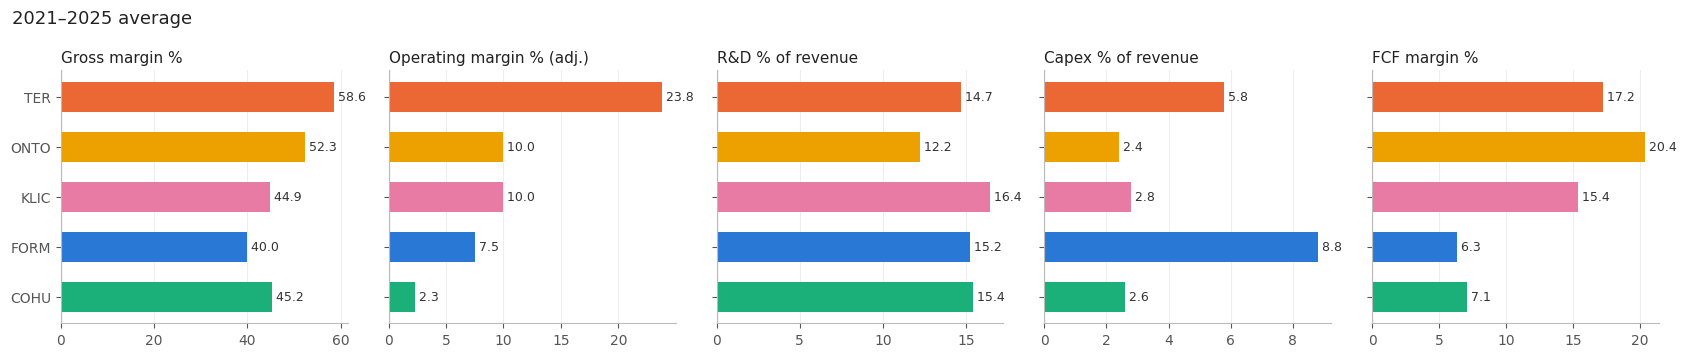

In [12]:
panels = [("gross_margin", "Gross margin %"), ("op_margin_adj", "Operating margin % (adj.)"),
          ("rd_pct", "R&D % of revenue"), ("capex_pct", "Capex % of revenue"), ("fcf_margin", "FCF margin %")]
order = avg5.sort_values("op_margin_adj")["ticker"].tolist()

fig, axes = plt.subplots(1, 5, figsize=(17, 3.6), sharey=True)
for ax, (col, title) in zip(axes, panels):
    d = avg5.set_index("ticker").loc[order, col]
    ax.barh(d.index, d.values, color=[COLORS[t] for t in d.index], height=0.6)
    for y, v in enumerate(d.values):
        ax.text(v, y, f" {v:.1f}", va="center", fontsize=9, color="#333333")
    ax.set_title(title, loc="left", fontsize=11, color="#222222")
    ax.axvline(0, color="#999999", linewidth=0.8)
    ax.grid(axis="x", color="#eeeeee")
    style(ax)
fig.suptitle("2021–2025 average", x=0.01, ha="left", fontsize=13, color="#222222")
plt.tight_layout()
plt.savefig(OUT_DIR / "peer_margins_5yr.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Cyclicality (2017–2025)

SQLite has no `STDEV()`, so SQL extracts the series and pandas computes volatility.

In [13]:
yoy = q("""
SELECT ticker, fiscal_year,
       100.0 * (revenue_musd - LAG(revenue_musd) OVER w) / LAG(revenue_musd) OVER w AS rev_yoy,
       operating_margin_pct
FROM ratios
WINDOW w AS (PARTITION BY ticker ORDER BY fiscal_year)
""")
cyc = (yoy[yoy["fiscal_year"] >= 2017]
       .groupby("ticker")
       .agg(avg_growth=("rev_yoy", "mean"), growth_volatility=("rev_yoy", "std"),
            worst_year=("rev_yoy", "min"), opm_volatility=("operating_margin_pct", "std"))
       .round(1)
       .sort_values("growth_volatility"))
cyc

,avg_growth,growth_volatility,worst_year,opm_volatility
ticker,,,,
FORM,9.20,15.90,-11.30,2.40
TER,8.10,16.90,-15.20,4.50
COHU,8.50,25.80,-36.90,14.10
ONTO,21.10,28.40,-18.80,14.90
KLIC,10.50,55.90,-50.60,13.90


## Export

In [14]:
latest.to_csv(OUT_DIR / "peer_latest_snapshot.csv", index=False)
avg5.to_csv(OUT_DIR / "peer_5yr_average.csv", index=False)
idx_wide.round(1).to_csv(OUT_DIR / "peer_revenue_index.csv")
cyc.to_csv(OUT_DIR / "peer_cyclicality.csv")
conn.close()

## Findings

- **Most stable revenue in the group.** FormFactor's revenue growth had the lowest volatility (σ = 15.9 pts) and the shallowest 2023 decline (−11.3% vs. −15.2% to −50.6% for peers), consistent with probe cards behaving more like consumables than capital equipment. The 2023 drop was industry-wide, not company-specific.
- **Limited upside in upcycles.** FormFactor also grew least in 2020–21. On a 2020 base its 2025 revenue index is 113, second behind Onto (181); on a 2019 base it ranks third. Conclusions that hold under both bases: Onto grew most, Cohu shrank most, FormFactor was the most stable.
- **Lowest gross margin and free-cash-flow margin.** 2021–25 average gross margin of 40.0% (peers 44.9–58.6%) and FCF margin of 6.3% (peers 7.1–20.4%).
- **R&D is not the outlier; capex is.** R&D intensity of 15.2% is mid-pack, while capex at 8.8% of revenue is roughly 1.5× Teradyne and over 3× the other peers. Low gross margin plus heavy capex explains the weak cash generation.